In [63]:
from sklearn.impute import KNNImputer
import pandas as pnd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.stats import zscore

In [64]:
path = r"C:\Users\aamir\Desktop\YC\P\smart-diabetes-detector\src\infrastructure\data\dataset-diabete-68e2810ab0d7e949117525.csv"
data = pnd.read_csv(path)

statisticDataFrame = pnd.DataFrame({"median": data.median()})
print(data.isnull().sum())
print(data.duplicated().sum())
print(data.info())
print(data.dtypes)

Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                768 non-null    int64  
 1   Pregnancies               768 non-null    int64  
 2   Glucose                   768 non-null    int64  
 3   BloodPressure             768 non-null    int64  
 4   SkinThickness             768 non-null    int64  
 5   Insulin                   768 non-null    int64  
 6   BMI                       768 non-null    float64
 7   DiabetesPedigreeFunction  768 non-null    float64
 8   Age                       768 non-null    int64  
dtypes

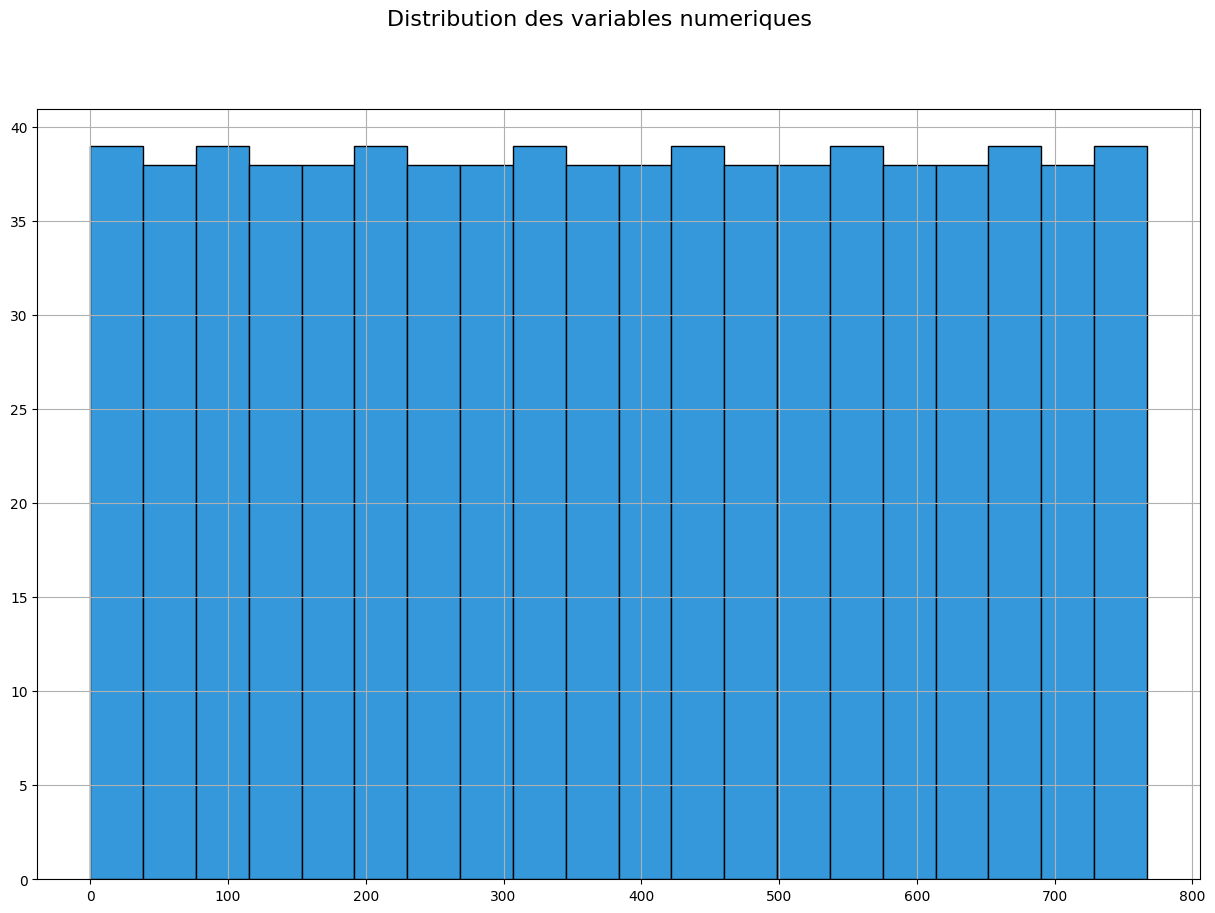

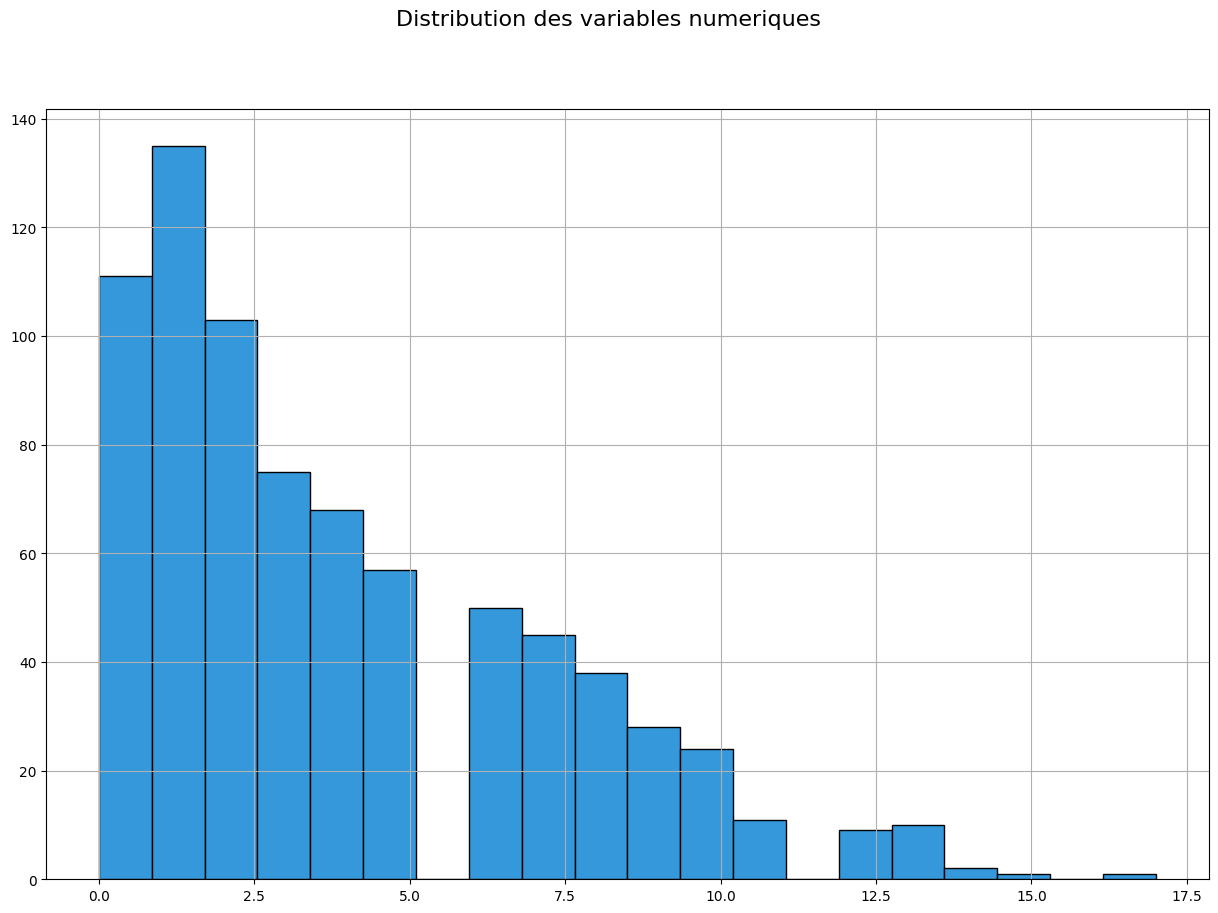

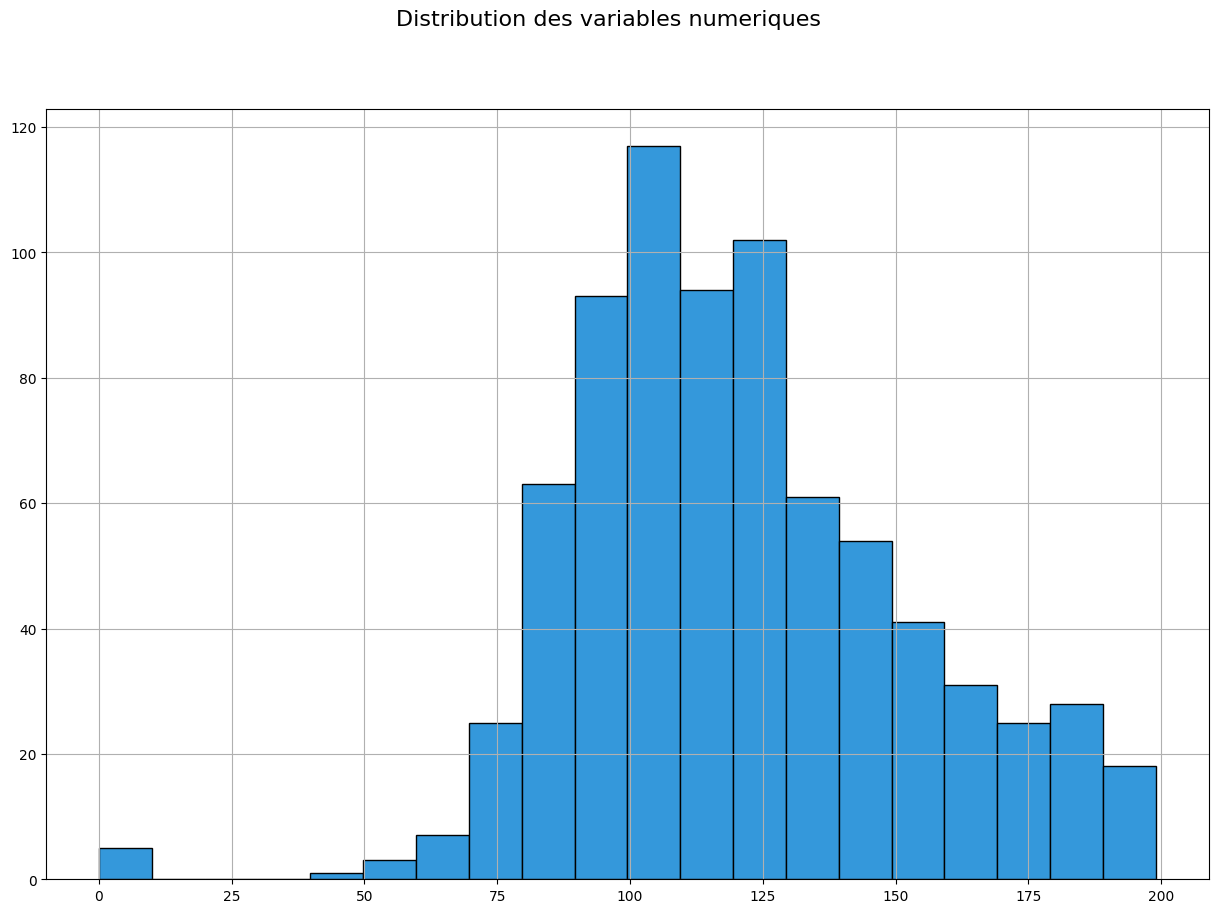

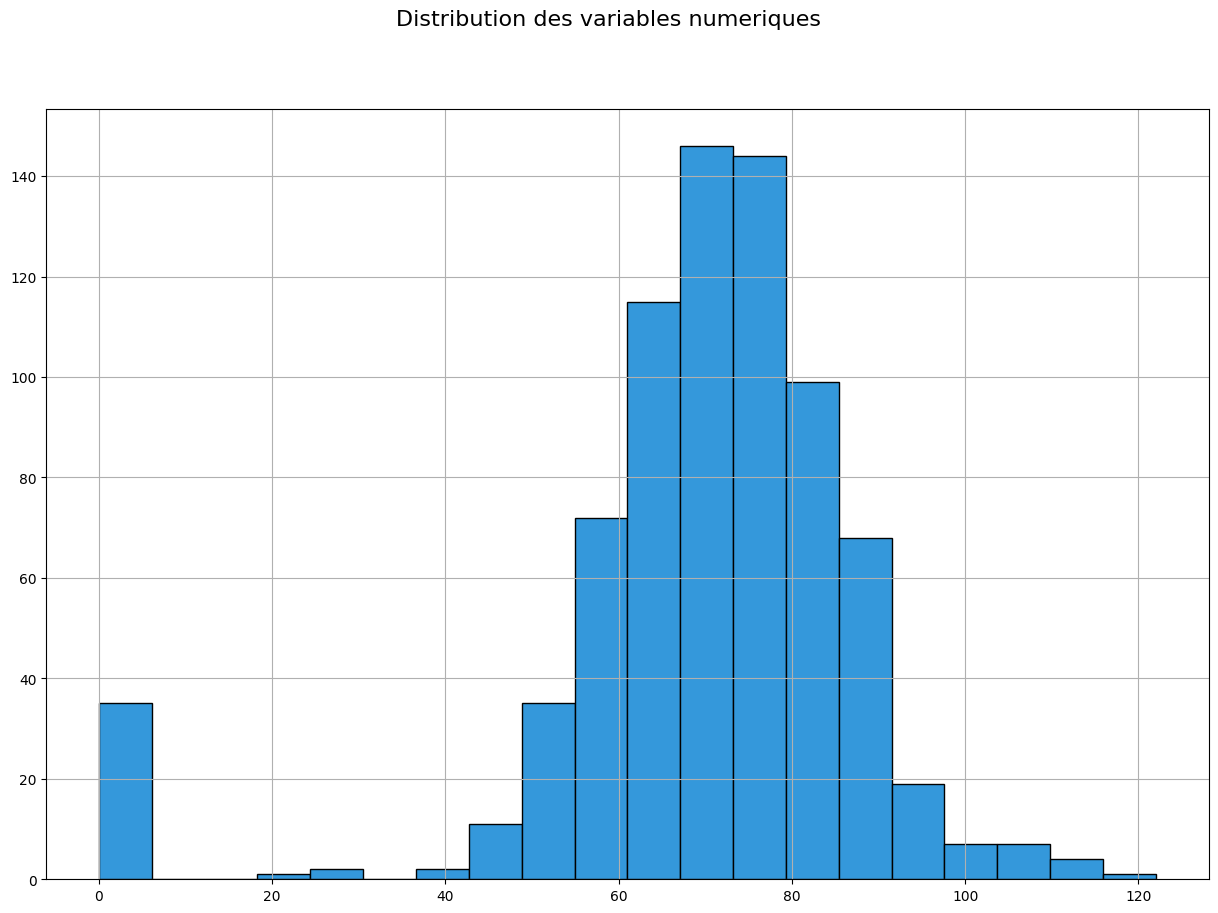

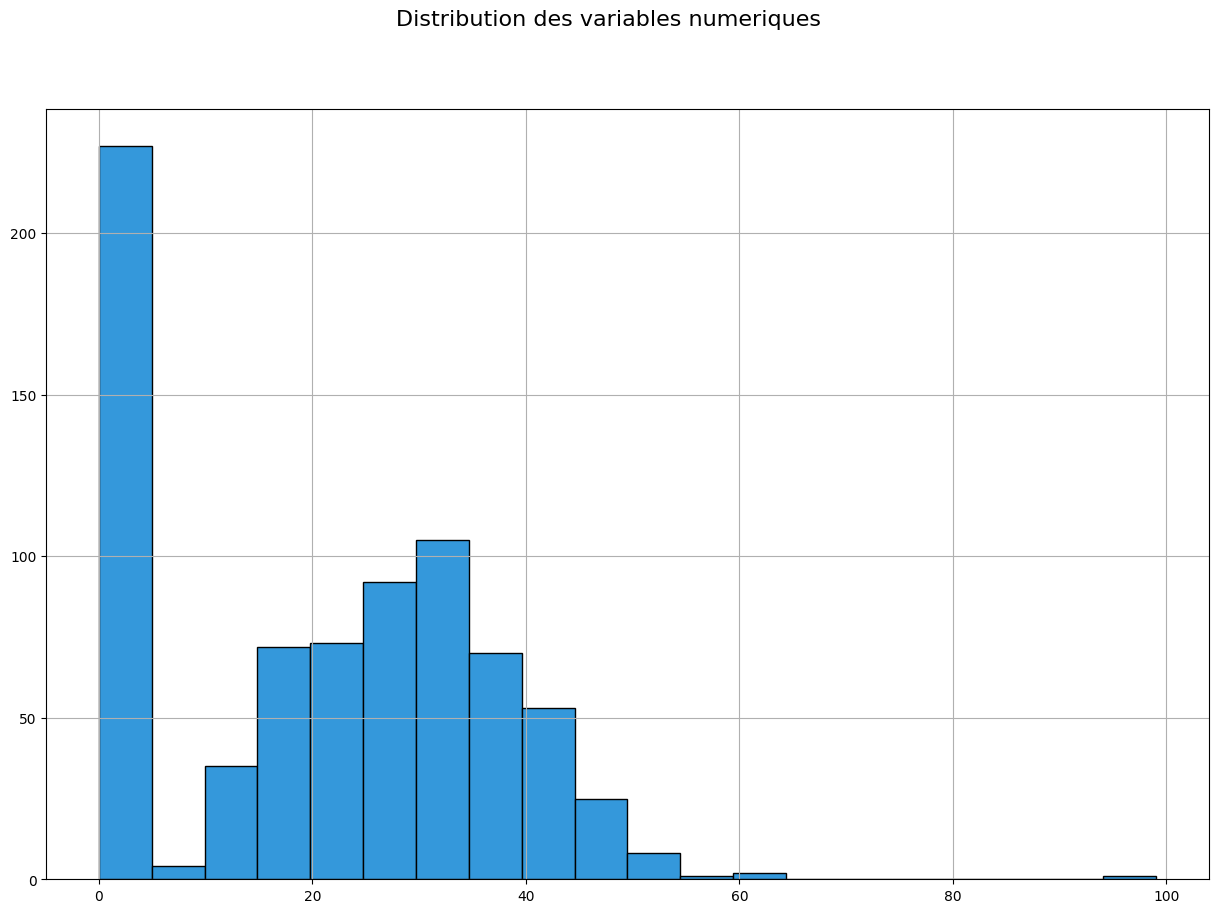

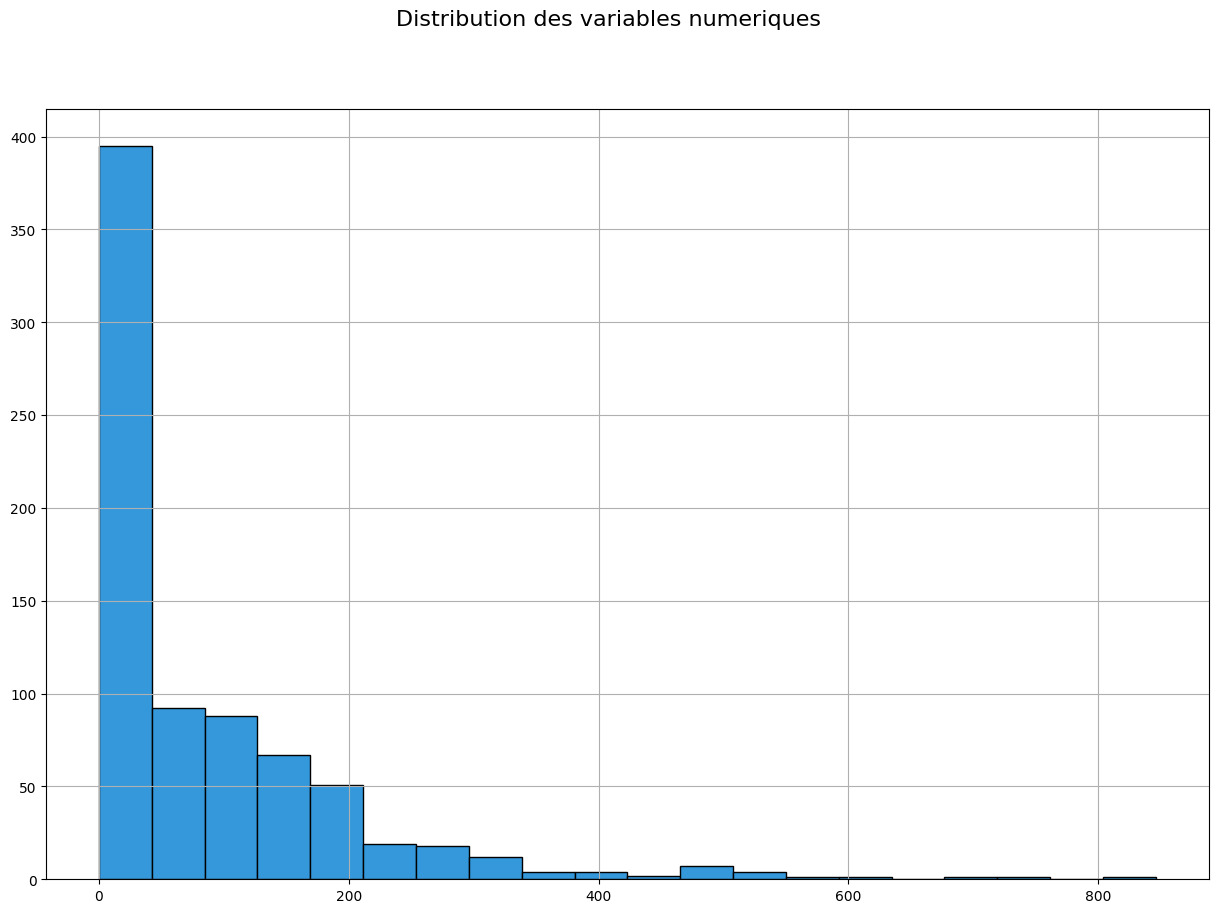

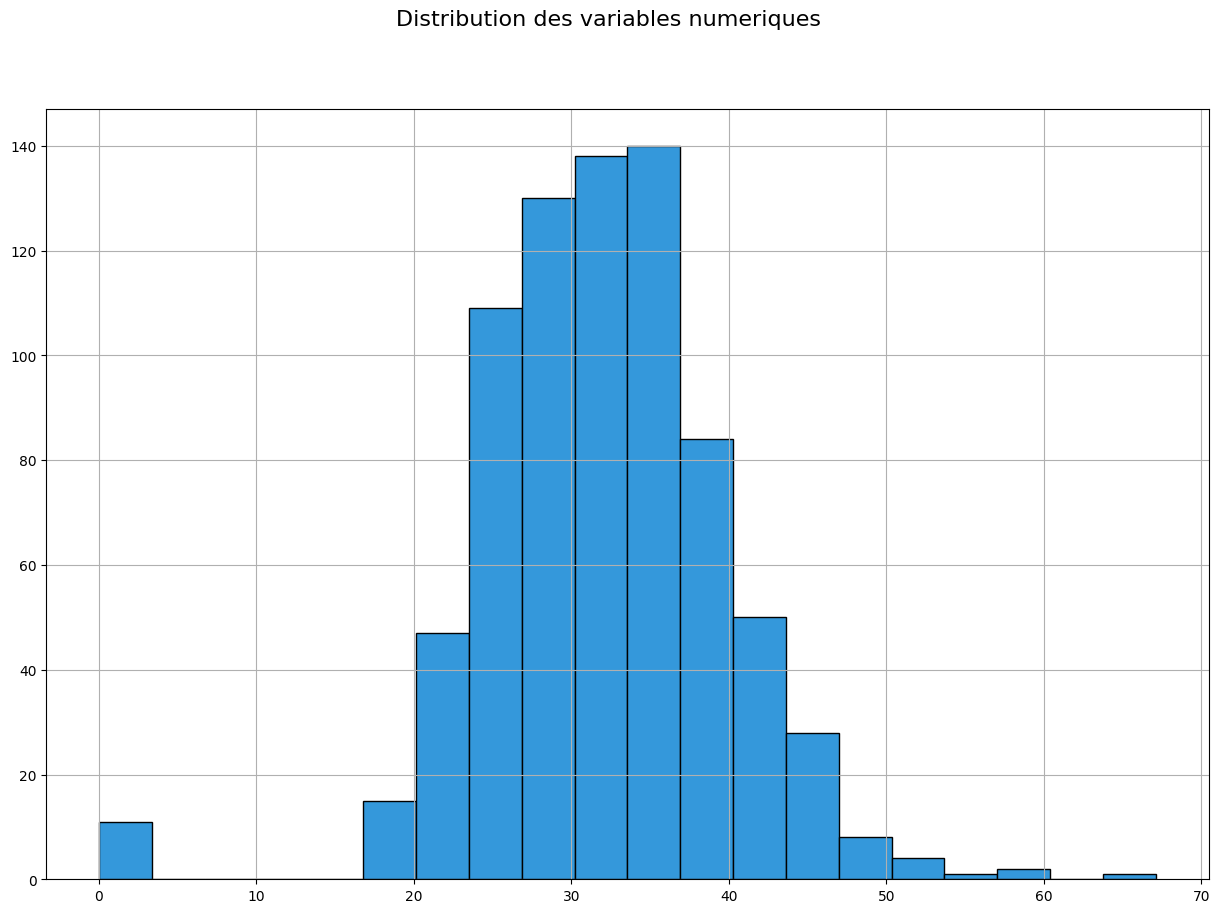

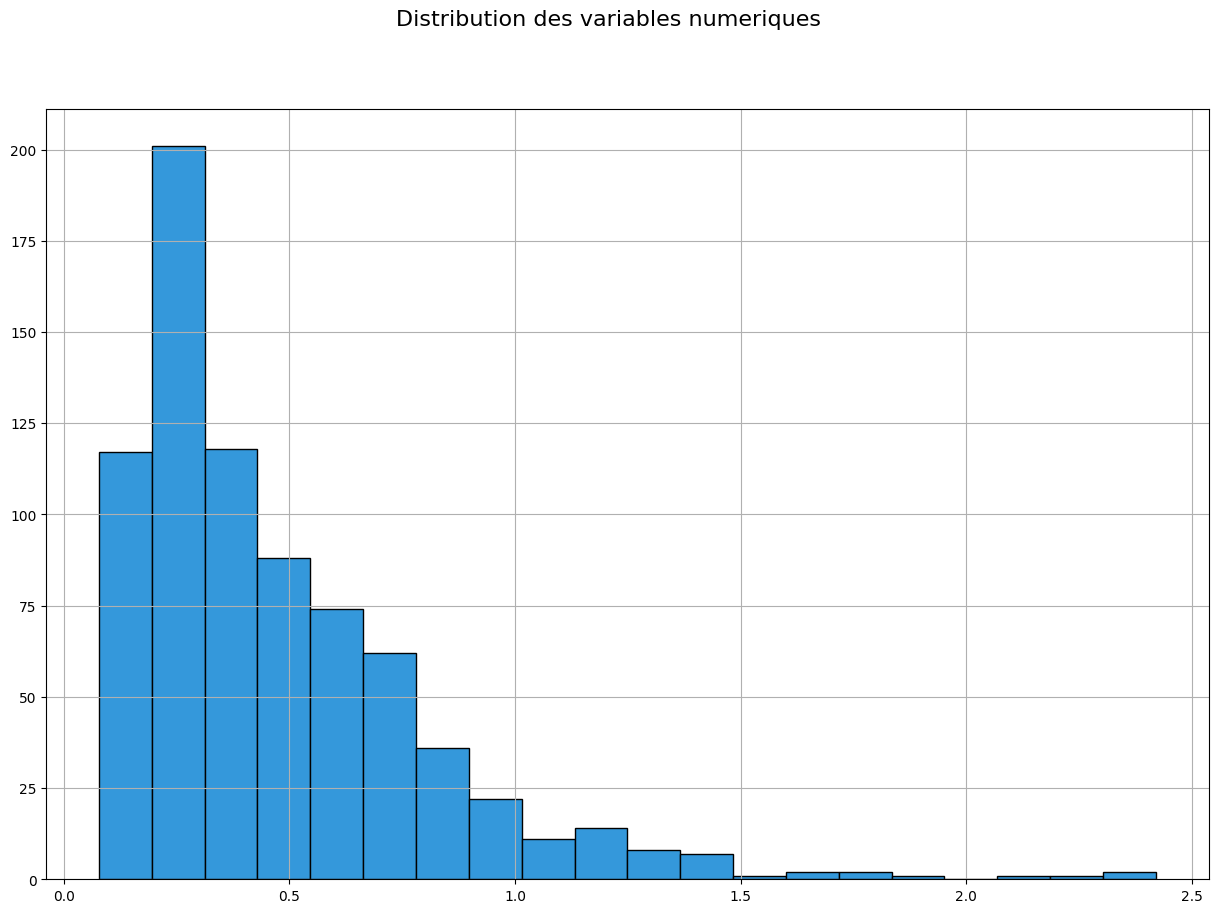

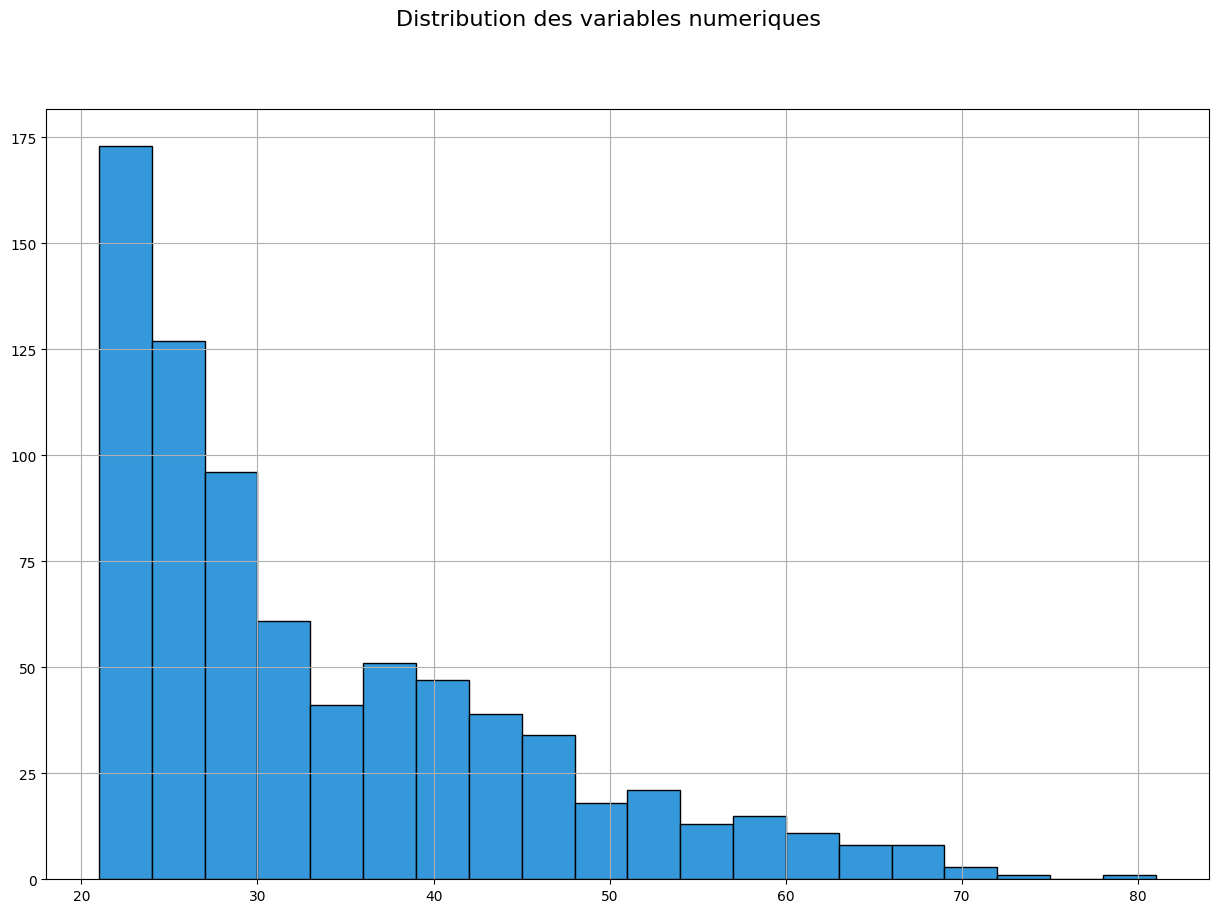

In [65]:
data_columns = data.select_dtypes(include=[np.number]).columns
for col in data_columns:
    plt.figure(figsize=(15, 10))
    data[col].hist(bins=20, color='#3498db', edgecolor='black')
    plt.suptitle("Distribution des variables numeriques", fontsize=16)
    plt.show()

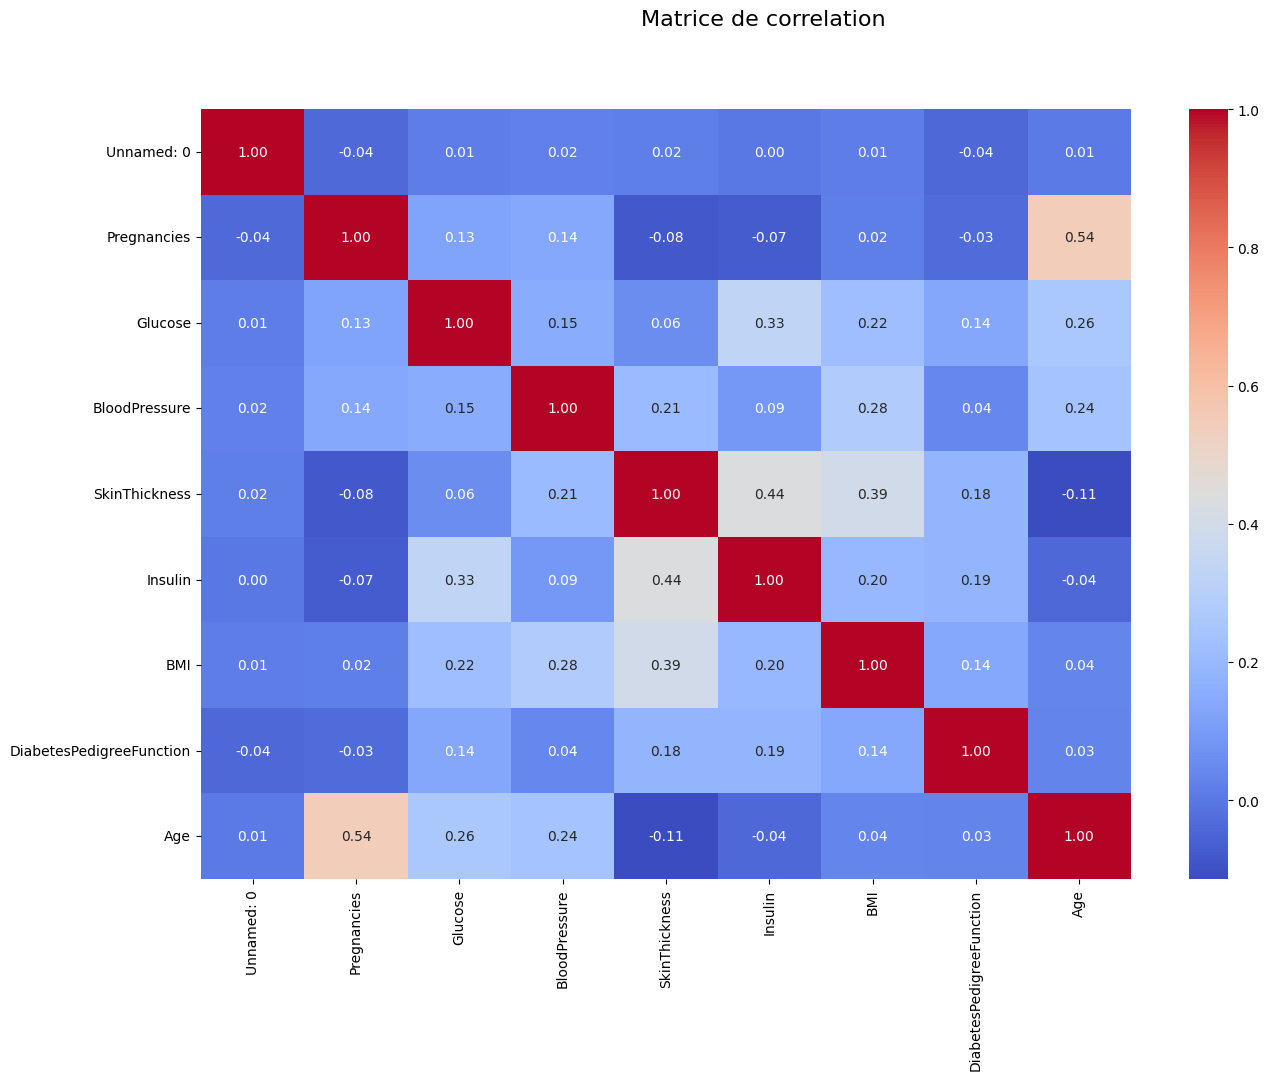

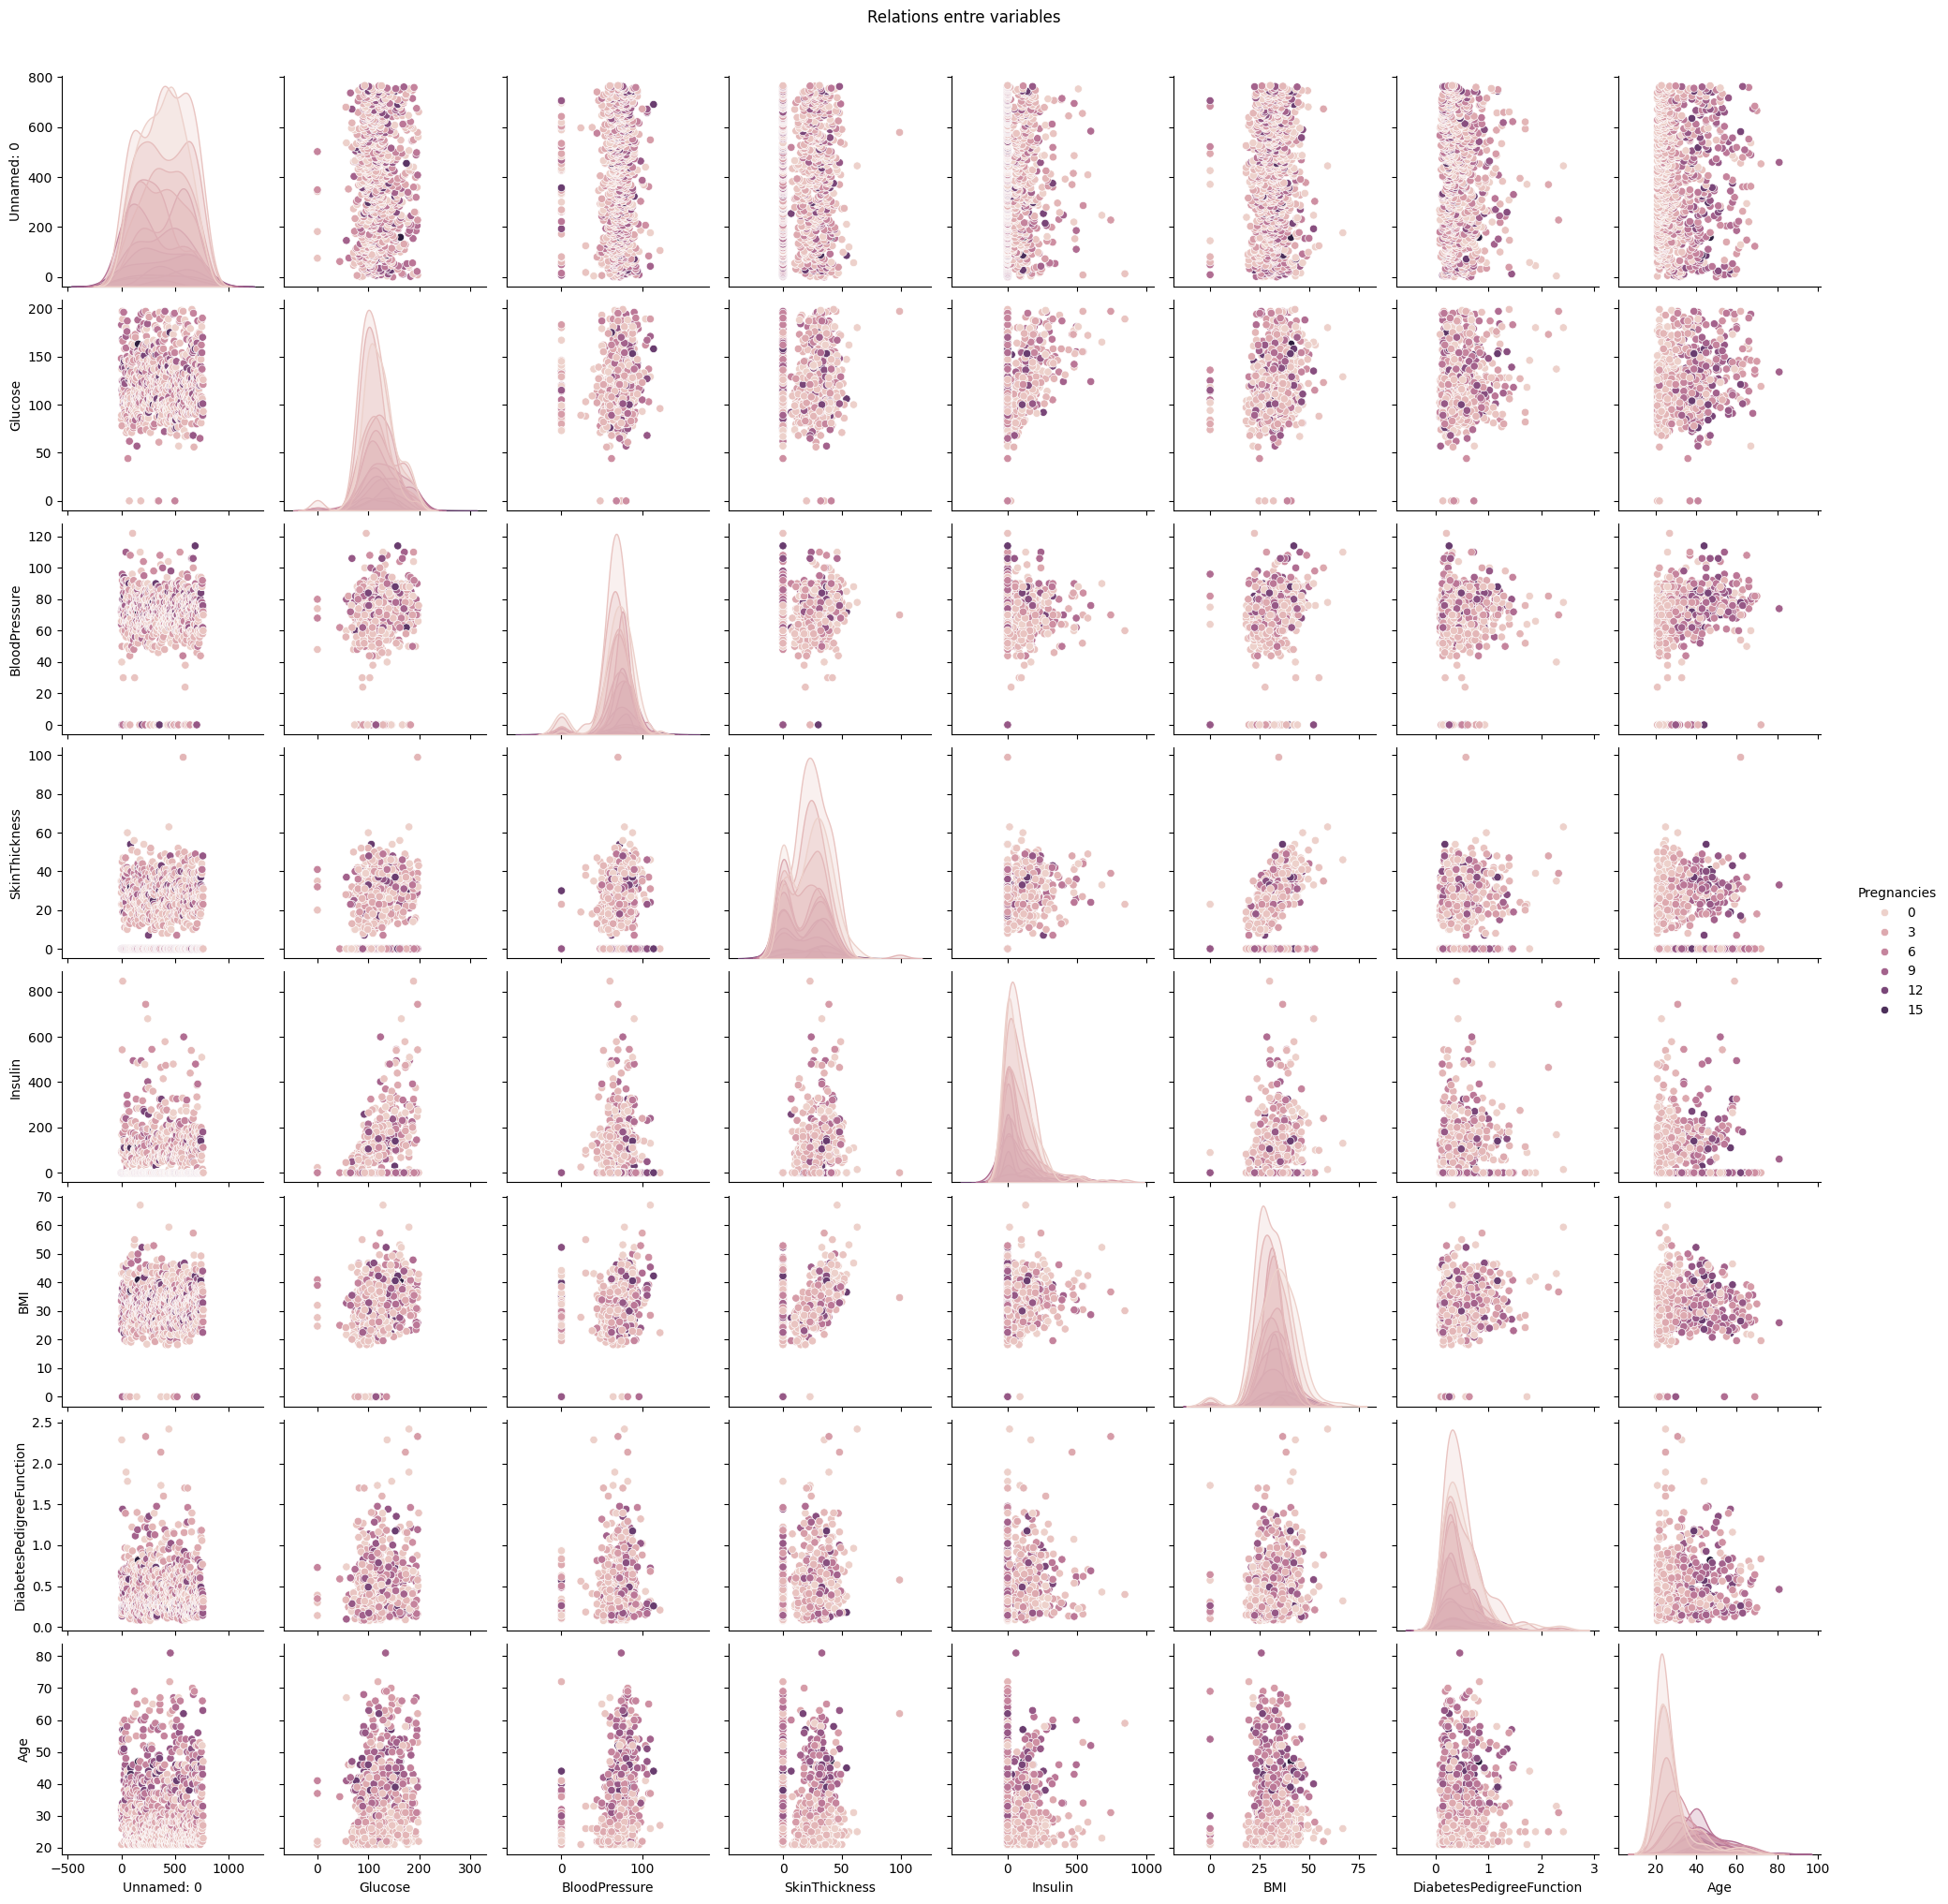

In [66]:
corr = data.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.suptitle("Matrice de correlation", fontsize=16)
plt.show()

sns.pairplot(data, diag_kind="kde", hue="Pregnancies")
plt.suptitle("Relations entre variables", y=1.02)
plt.show()



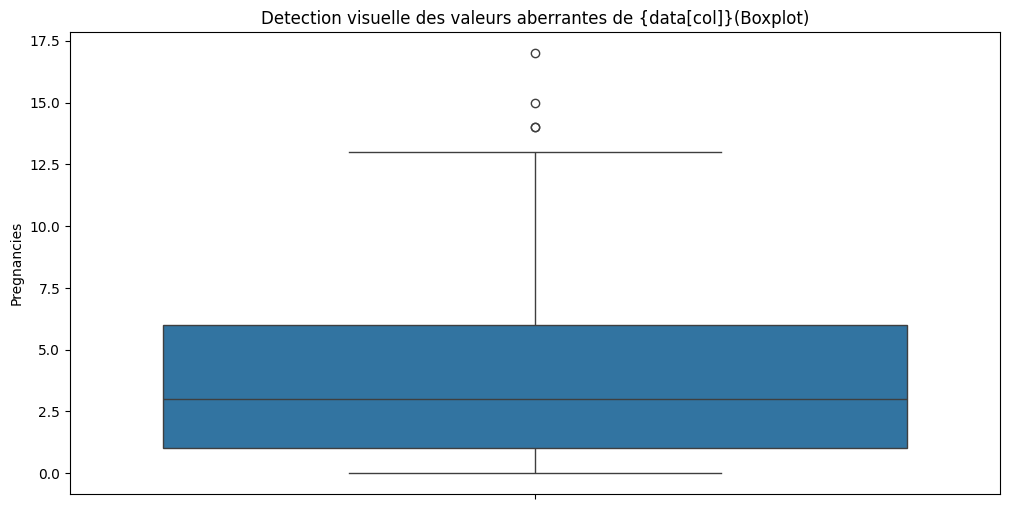

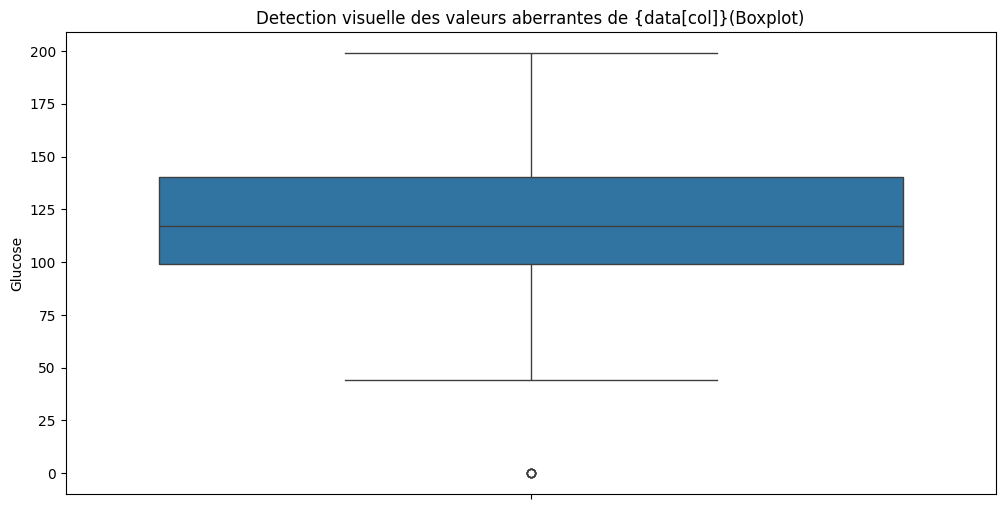

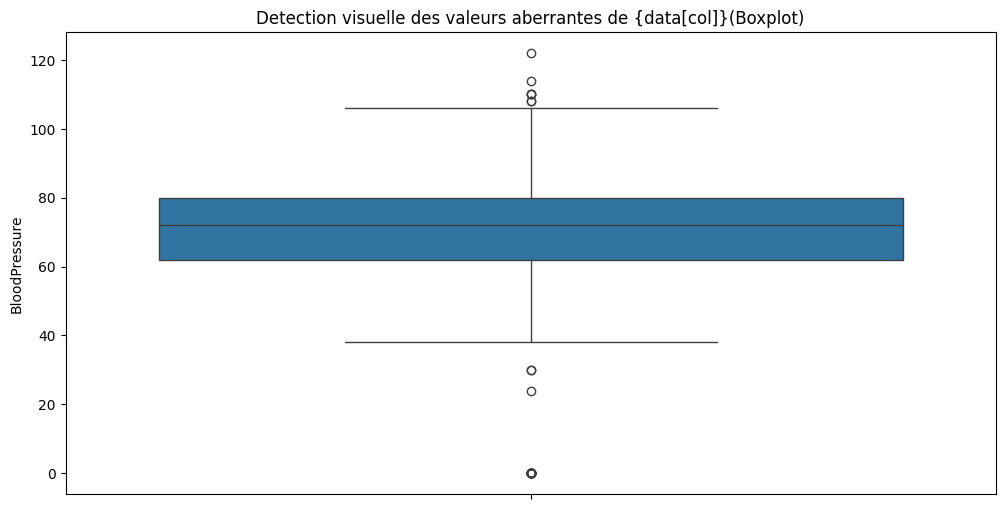

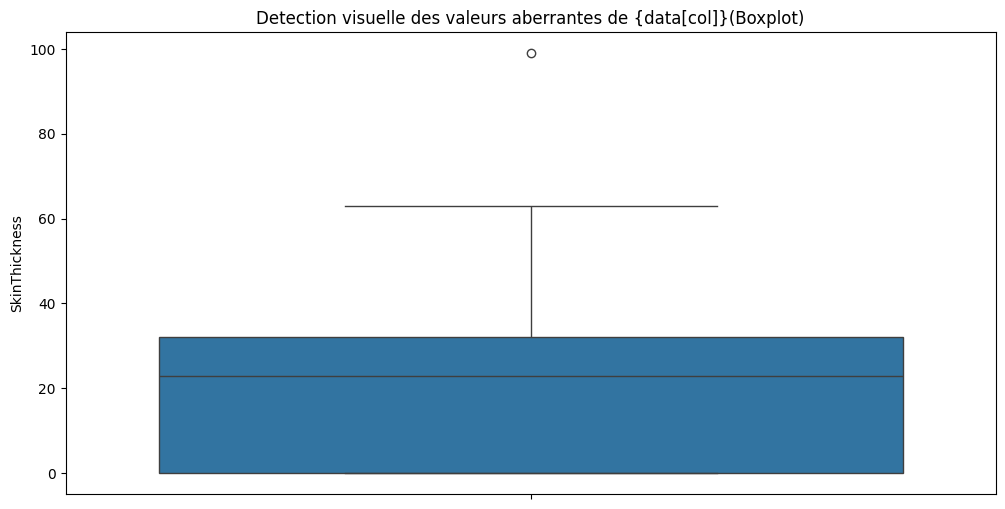

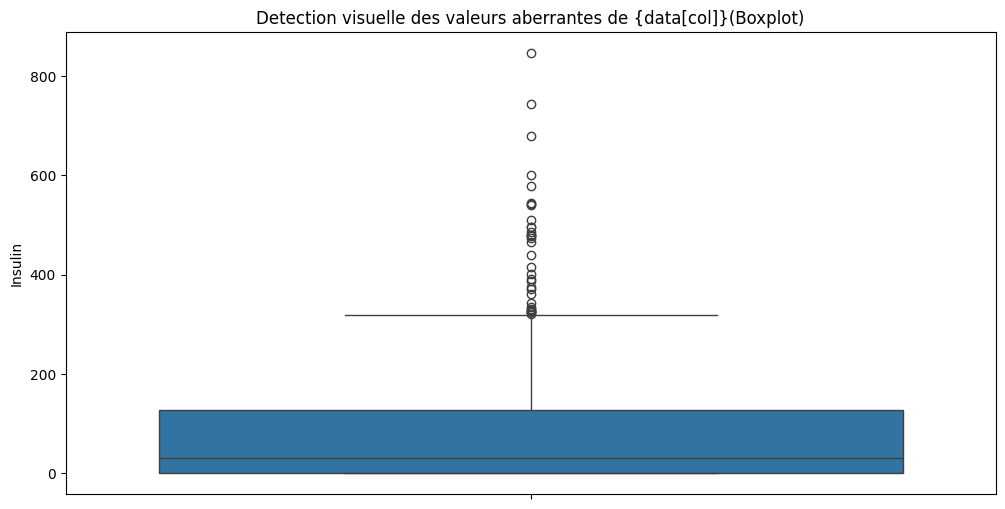

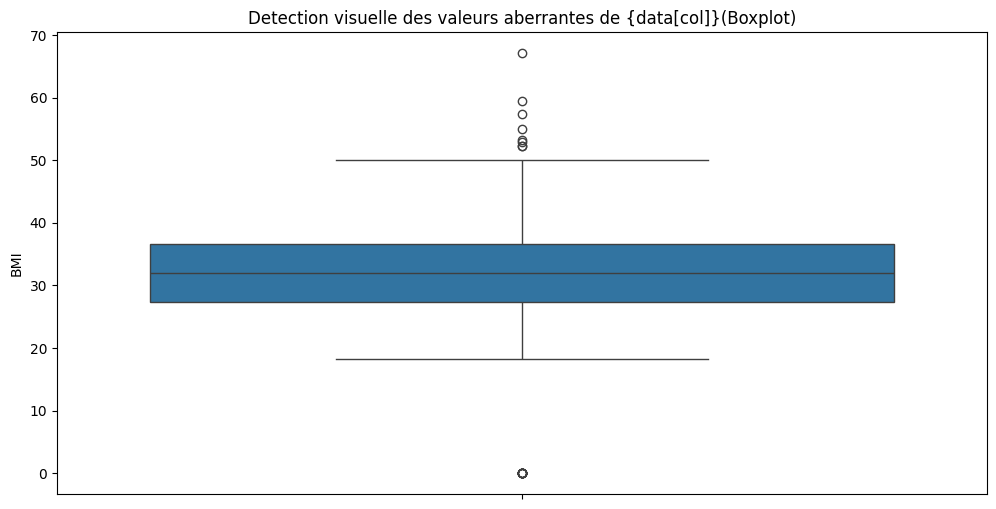

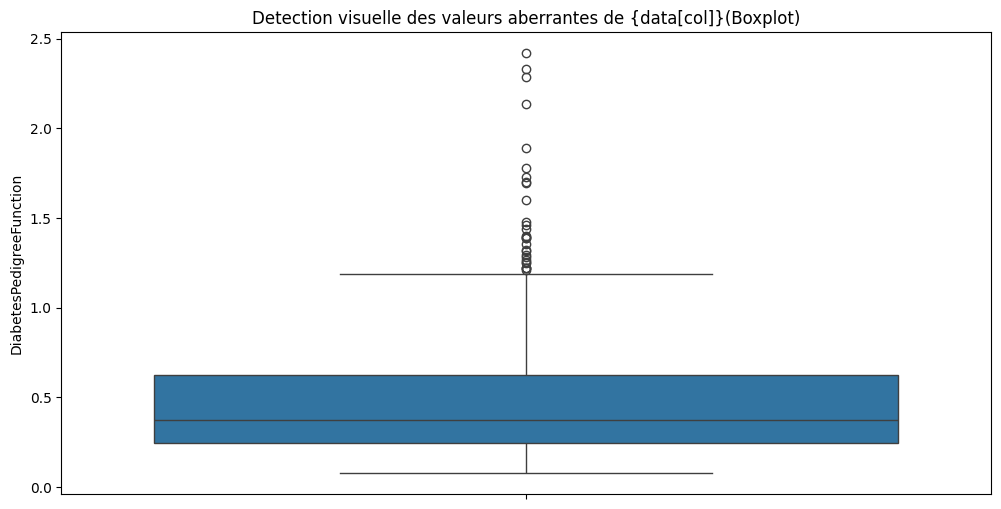

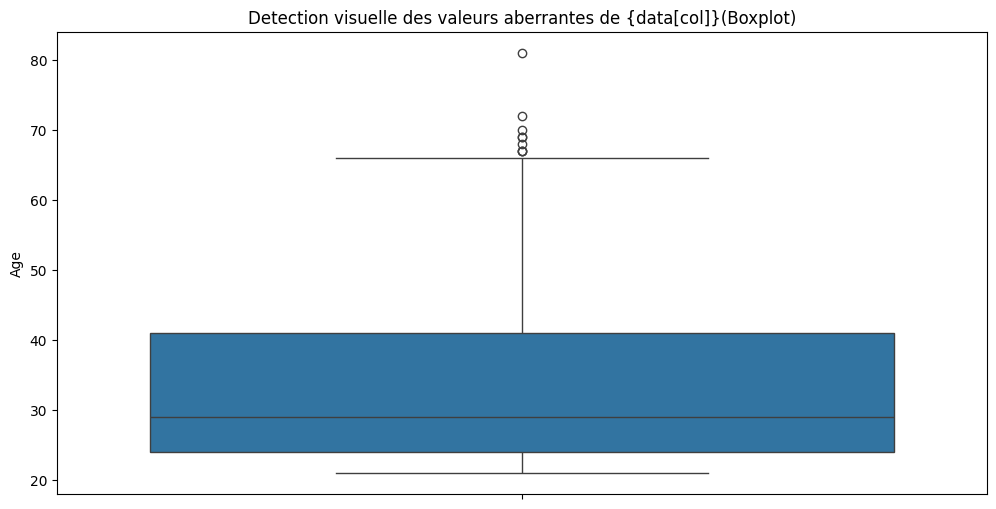

In [67]:
cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", 
        "DiabetesPedigreeFunction", "Age"]
for col in cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=data[col])
    plt.title("Detection visuelle des valeurs aberrantes de {data[col]}(Boxplot)")
    plt.show()

In [68]:
cols_to_replace = ['Glucose', 'BloodPressure', 'BMI']
data[cols_to_replace] = data[cols_to_replace].replace(0, np.nan)

imputer = KNNImputer(n_neighbors=2)
data_imputed = pnd.DataFrame(imputer.fit_transform(data), columns=data.columns)

print("\nValeurs manquantes après imputation KNN :")
print(data_imputed.isnull().sum())


Valeurs manquantes après imputation KNN :
Unnamed: 0                  0
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


In [69]:
z_scores = np.abs(zscore(data_imputed[cols]))
outliers = (z_scores > 3)
print(f"\nNombre total de valeurs aberrantes détectées (Z-Score) : {np.sum(outliers)}")

cleanData = data_imputed[(z_scores < 3).all(axis=1)]
print(f"Forme après suppression des outliers : {cleanData.shape}")


Nombre total de valeurs aberrantes détectées (Z-Score) : 52
Forme après suppression des outliers : (721, 9)


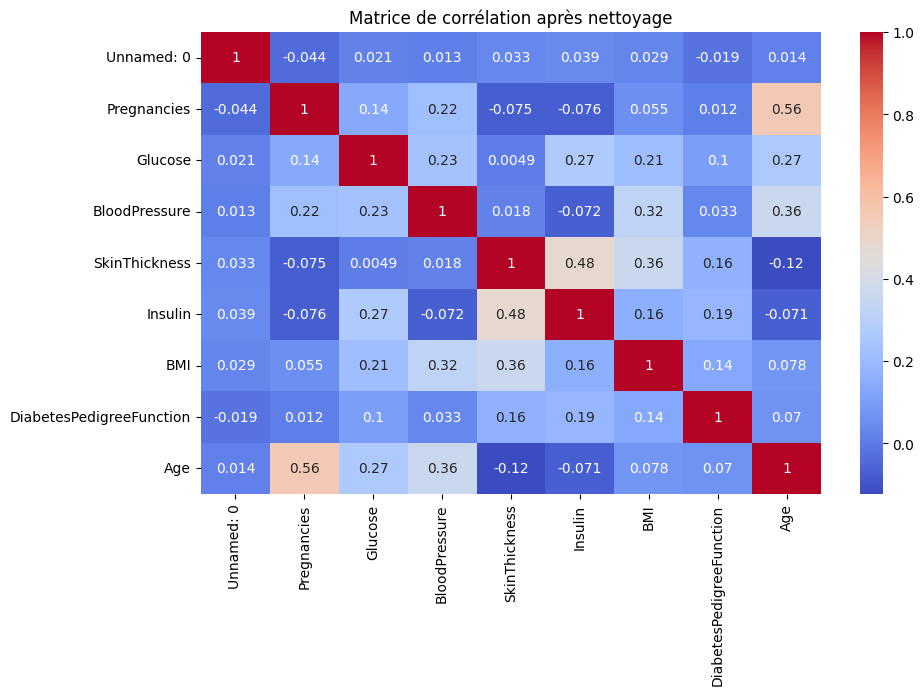

In [70]:
scaler = StandardScaler()
num_cols = cleanData.select_dtypes(include=[np.number]).columns
data_scaled = cleanData.copy()
data_scaled[num_cols] = scaler.fit_transform(cleanData[num_cols])

corr_MAT = data_scaled.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_MAT, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation après nettoyage")
plt.show()


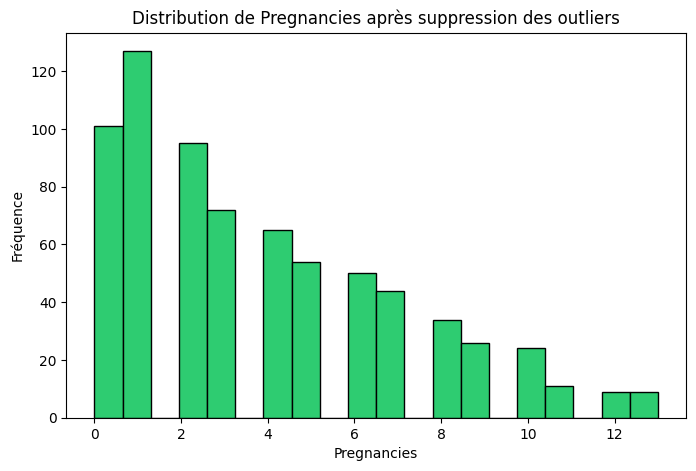

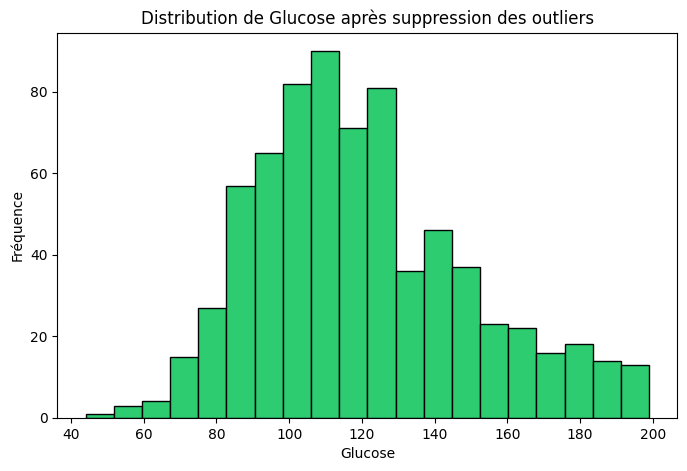

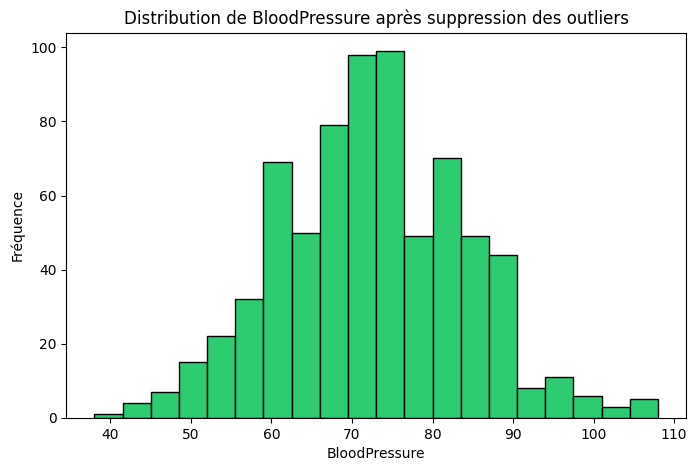

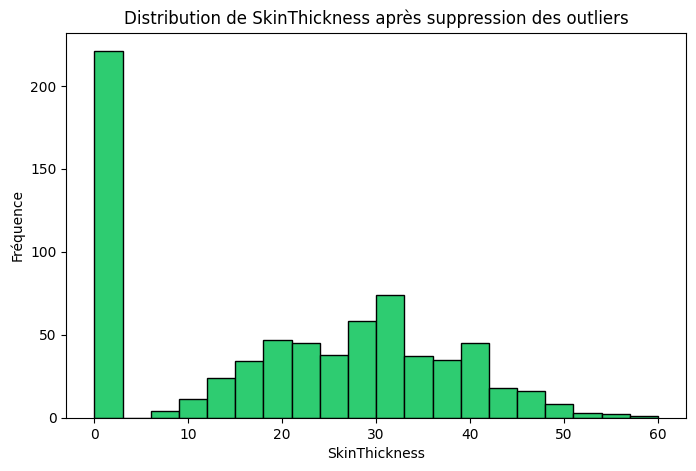

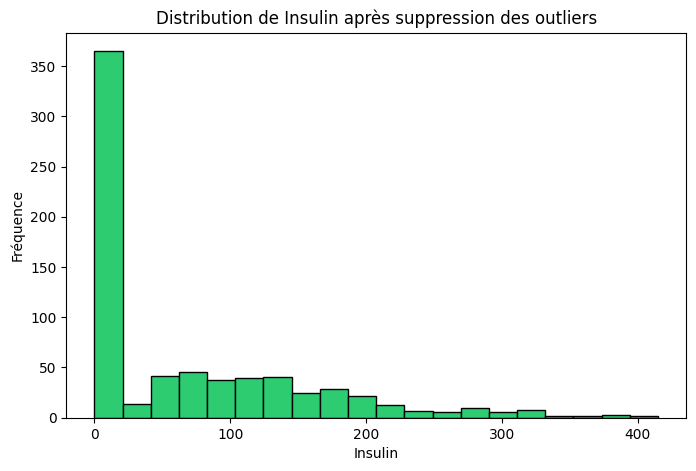

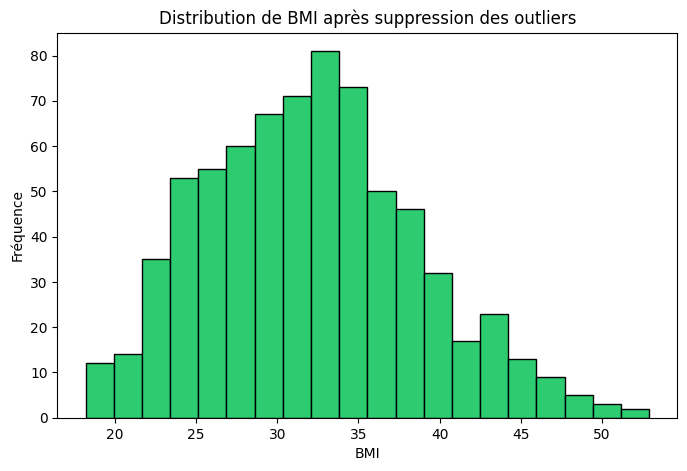

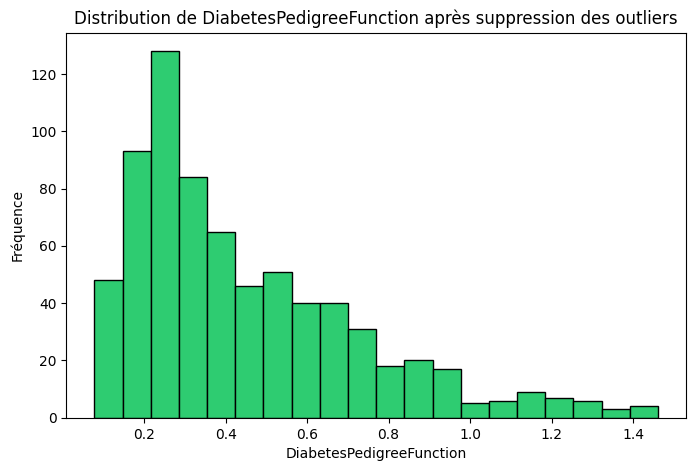

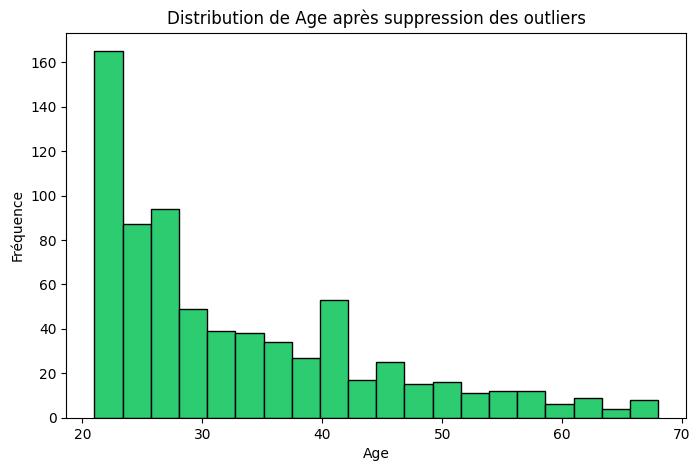

In [71]:
for col in cols:
    plt.figure(figsize=(8, 5))
    plt.hist(cleanData[col], bins=20, color='#2ecc71', edgecolor='black')
    plt.title(f"Distribution de {col} après suppression des outliers")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

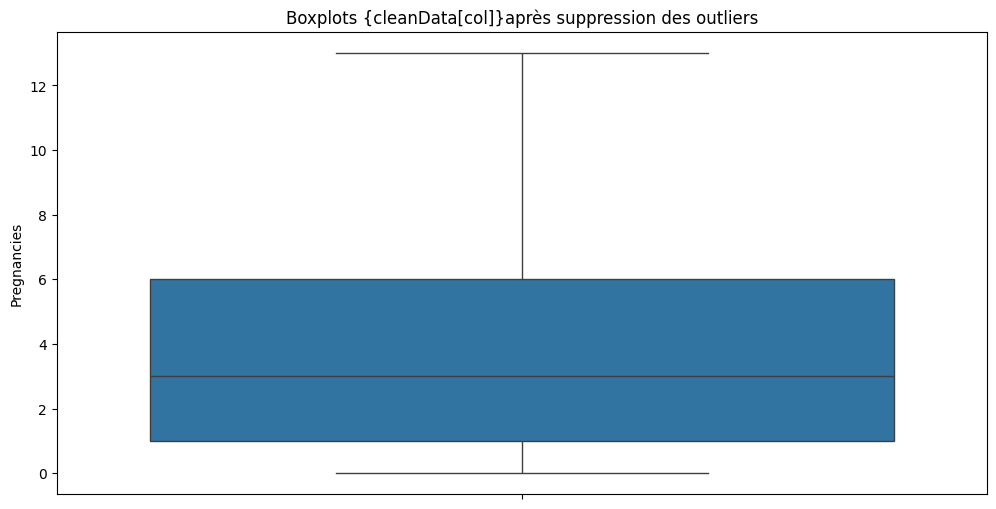

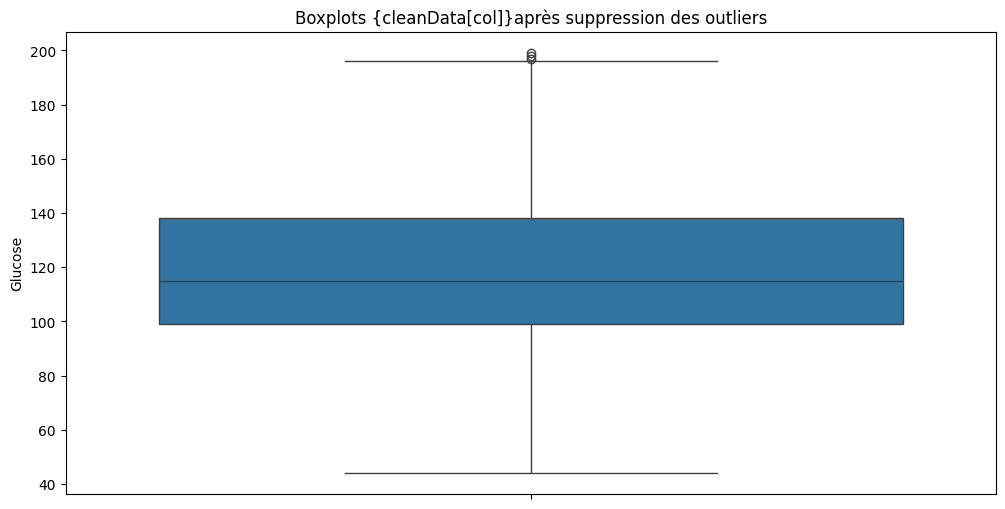

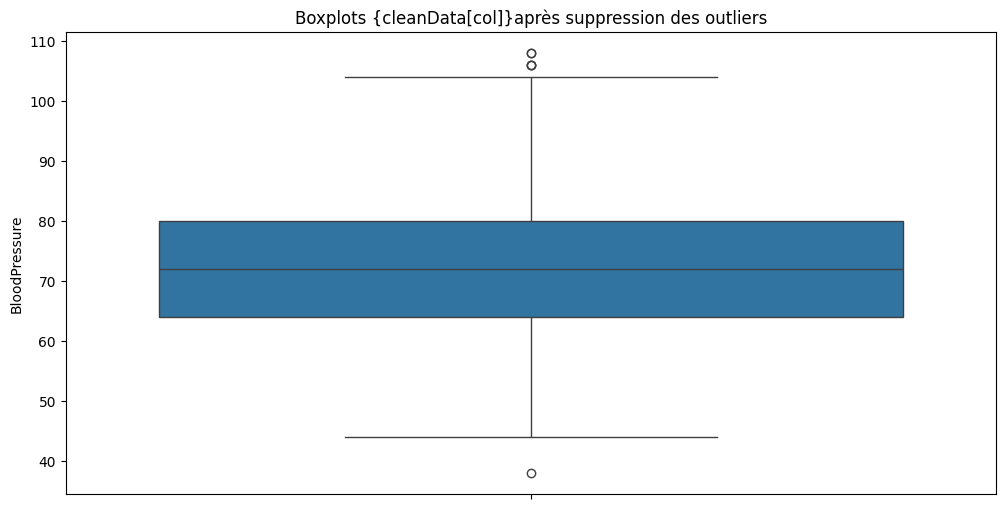

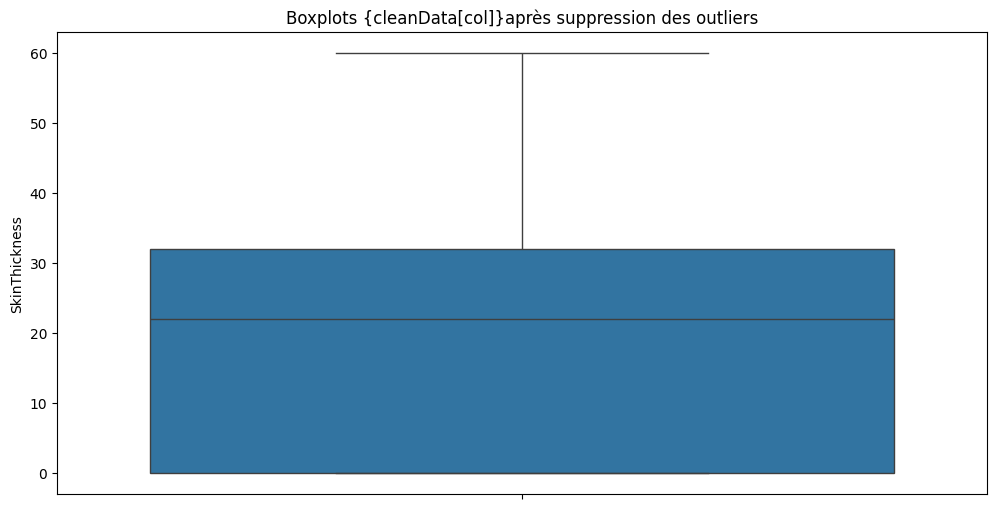

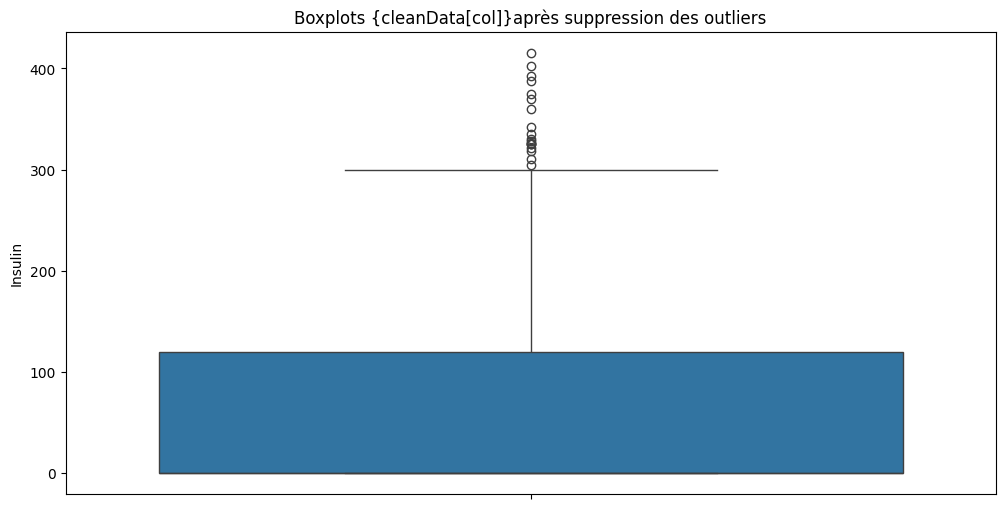

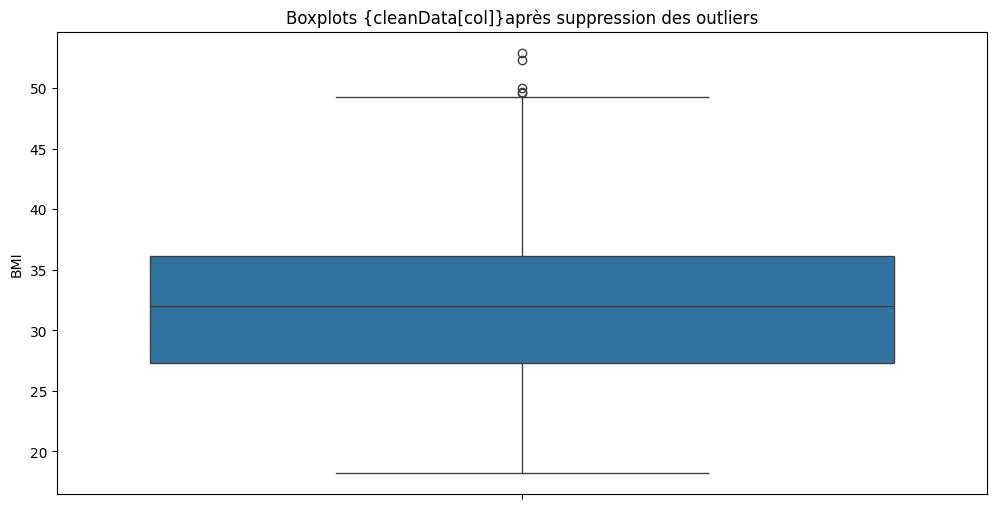

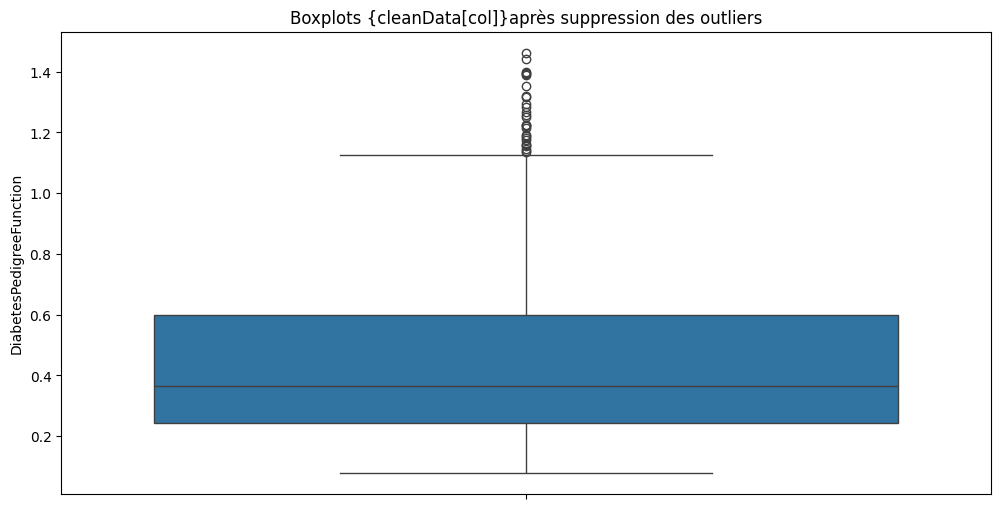

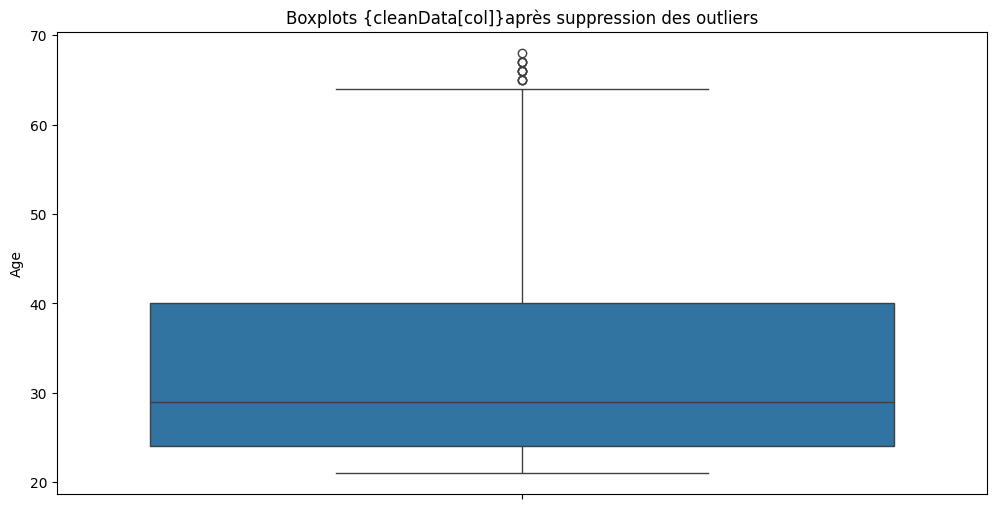

In [72]:
for col in cols:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=cleanData[col])
    plt.title("Boxplots {cleanData[col]}après suppression des outliers")
    plt.show()

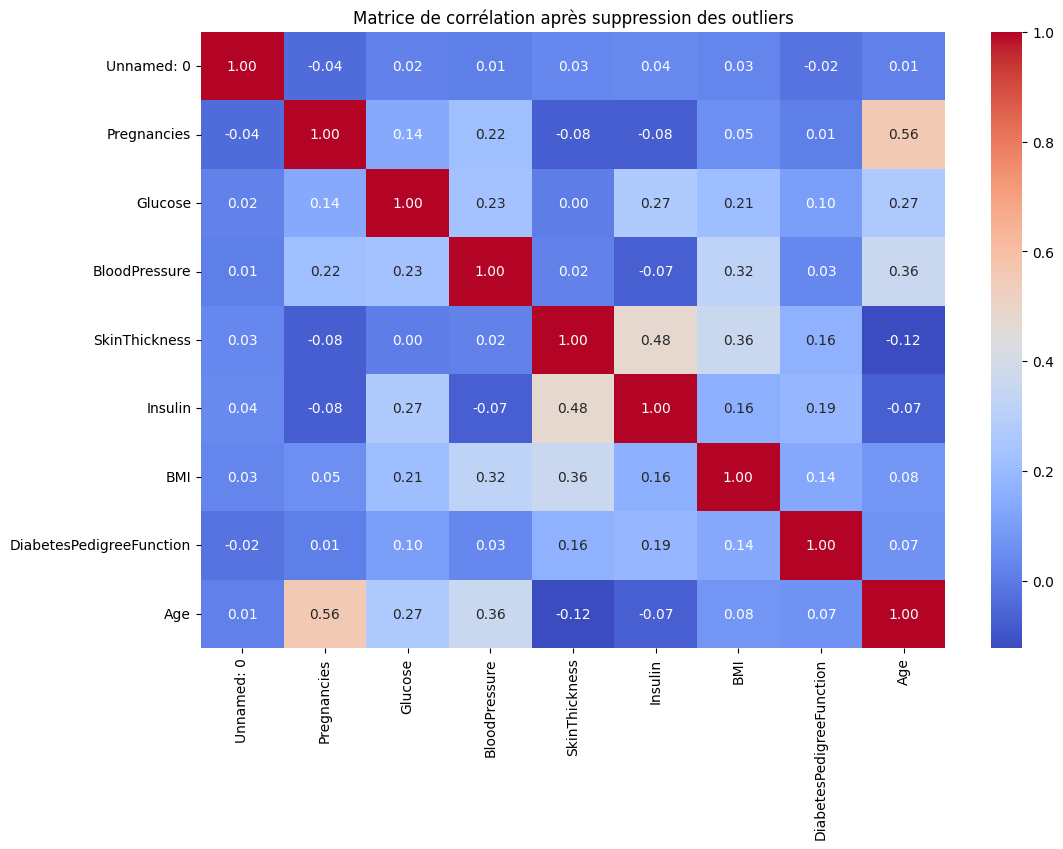

In [117]:
corr_clean = cleanData.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_clean, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation après suppression des outliers")
plt.show()

# sns.pairplot(cleanData[cols], diag_kind="kde")
# plt.suptitle("Relations entre variables après suppression des outliers", y=1.02)
# plt.show()


In [74]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = list(range(2, 11))
inertias = []
sil_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_scaled[num_cols])
    inertias.append(kmeans.inertia_)
    try:
        sil = silhouette_score(data_scaled[num_cols], labels)
    except Exception as e:
        sil = np.nan
    sil_scores.append(sil)


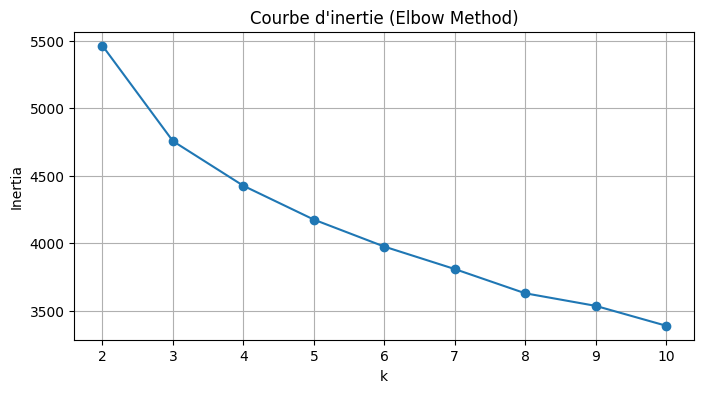

In [75]:
plt.figure(figsize=(8, 4))
plt.plot(ks, inertias, marker='o')
plt.title("Courbe d'inertie (Elbow Method)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

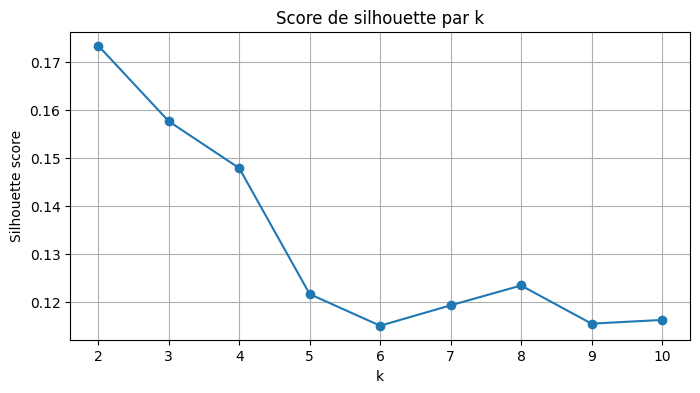

In [76]:
plt.figure(figsize=(8, 4))
plt.plot(ks, sil_scores, marker='o')
plt.title("Score de silhouette par k")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

In [77]:
k_opt_index = int(np.argmax(sil_scores))
k_opt = ks[k_opt_index]
print(f"k suggere (max silhouette): {k_opt} (silhouette={sil_scores[k_opt_index]:.4f})")


k suggere (max silhouette): 2 (silhouette=0.1734)


In [78]:
kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=20)
clusters = kmeans_final.fit_predict(data_scaled[num_cols])
data_with_clusters = cleanData.copy()
data_with_clusters['Cluster'] = clusters

In [79]:
cluster_counts = data_with_clusters['Cluster'].value_counts().sort_index()
print("Taille par cluster :")
print(cluster_counts)

Taille par cluster :
Cluster
0    271
1    450
Name: count, dtype: int64


In [80]:
cluster_means = data_with_clusters.groupby('Cluster')[num_cols].mean()
print("\nMoyennes par cluster (donnees originales non-scalee) :")
print(cluster_means)


Moyennes par cluster (donnees originales non-scalee) :
         Unnamed: 0  Pregnancies     Glucose  BloodPressure  SkinThickness  \
Cluster                                                                      
0        368.151292     6.808118  131.322878       78.48155      15.675277   
1        396.377778     2.040000  113.073333       68.63000      22.373333   

           Insulin        BMI  DiabetesPedigreeFunction        Age  
Cluster                                                             
0        49.450185  33.226384                  0.461148  43.915129  
1        79.911111  31.408556                  0.443042  26.271111  


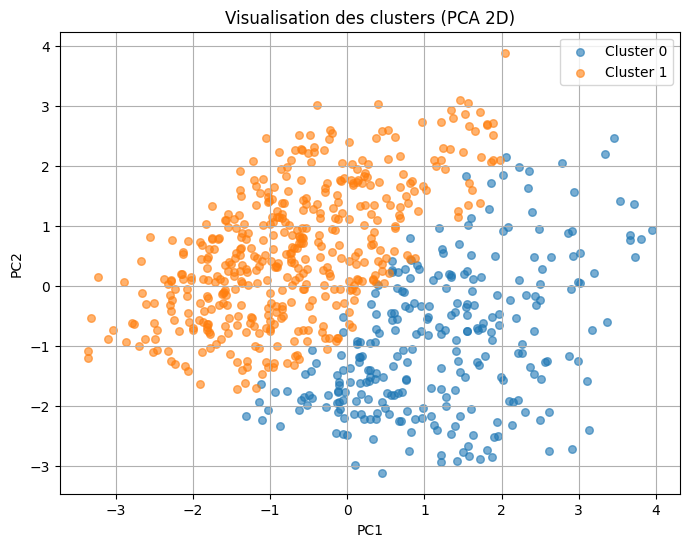

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(data_scaled[num_cols])
plt.figure(figsize=(8, 6))
for cl in sorted(np.unique(clusters)):
    mask = clusters == cl
    plt.scatter(coords[mask, 0], coords[mask, 1], label=f"Cluster {cl}", alpha=0.6, s=30)
plt.title("Visualisation des clusters (PCA 2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()


In [82]:
centers_scaled = kmeans_final.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)
centers_df = pnd.DataFrame(centers_original, columns=num_cols)
print("\nCentres de clusters (échelle originale) :")
print(centers_df)


Centres de clusters (échelle originale) :
   Unnamed: 0  Pregnancies     Glucose  BloodPressure  SkinThickness  \
0  368.151292     6.808118  131.322878       78.48155      15.675277   
1  396.377778     2.040000  113.073333       68.63000      22.373333   

     Insulin        BMI  DiabetesPedigreeFunction        Age  
0  49.450185  33.226384                  0.461148  43.915129  
1  79.911111  31.408556                  0.443042  26.271111  


In [83]:
print("\nExtrait des données avec cluster :")
print(data_with_clusters.head())


Extrait des données avec cluster :
   Unnamed: 0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0         0.0          6.0    148.0           72.0           35.0      0.0   
1         1.0          1.0     85.0           66.0           29.0      0.0   
2         2.0          8.0    183.0           64.0            0.0      0.0   
3         3.0          1.0     89.0           66.0           23.0     94.0   
5         5.0          5.0    116.0           74.0            0.0      0.0   

    BMI  DiabetesPedigreeFunction   Age  Cluster  
0  33.6                     0.627  50.0        0  
1  26.6                     0.351  31.0        1  
2  23.3                     0.672  32.0        0  
3  28.1                     0.167  21.0        1  
5  25.6                     0.201  30.0        0  


In [84]:
print(cluster_means)

         Unnamed: 0  Pregnancies     Glucose  BloodPressure  SkinThickness  \
Cluster                                                                      
0        368.151292     6.808118  131.322878       78.48155      15.675277   
1        396.377778     2.040000  113.073333       68.63000      22.373333   

           Insulin        BMI  DiabetesPedigreeFunction        Age  
Cluster                                                             
0        49.450185  33.226384                  0.461148  43.915129  
1        79.911111  31.408556                  0.443042  26.271111  


In [85]:
inversTrensform = pnd.DataFrame(
    scaler.inverse_transform(cluster_means),
    columns=cluster_means.columns,
    index=cluster_means.index
)

In [ ]:
high_risk_clusters = inversTrensform[
    (inversTrensform['Glucose'] > 126) &
    (inversTrensform['BMI'] > 30) &
    (inversTrensform['DiabetesPedigreeFunction'] > 0.5)
].index

print("Clusters a haut risque :", list(high_risk_clusters))
    

Clusters à haut risque : [0, 1]


In [87]:
data_with_clusters['risk_category'] = data_with_clusters['Cluster'].apply(
    lambda x: 'High Risk' if x in high_risk_clusters else 'Low Risk'
)


In [88]:
print(data_with_clusters.head())


   Unnamed: 0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0         0.0          6.0    148.0           72.0           35.0      0.0   
1         1.0          1.0     85.0           66.0           29.0      0.0   
2         2.0          8.0    183.0           64.0            0.0      0.0   
3         3.0          1.0     89.0           66.0           23.0     94.0   
5         5.0          5.0    116.0           74.0            0.0      0.0   

    BMI  DiabetesPedigreeFunction   Age  Cluster risk_category  
0  33.6                     0.627  50.0        0     High Risk  
1  26.6                     0.351  31.0        1     High Risk  
2  23.3                     0.672  32.0        0     High Risk  
3  28.1                     0.167  21.0        1     High Risk  
5  25.6                     0.201  30.0        0     High Risk  


In [89]:
data_with_clusters['risk_category'] = np.where(
    data_with_clusters['Cluster'] == 1,
    'High Risk',
    'Low Risk'
)


In [90]:
print(data_with_clusters.head())


   Unnamed: 0  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  \
0         0.0          6.0    148.0           72.0           35.0      0.0   
1         1.0          1.0     85.0           66.0           29.0      0.0   
2         2.0          8.0    183.0           64.0            0.0      0.0   
3         3.0          1.0     89.0           66.0           23.0     94.0   
5         5.0          5.0    116.0           74.0            0.0      0.0   

    BMI  DiabetesPedigreeFunction   Age  Cluster risk_category  
0  33.6                     0.627  50.0        0      Low Risk  
1  26.6                     0.351  31.0        1     High Risk  
2  23.3                     0.672  32.0        0      Low Risk  
3  28.1                     0.167  21.0        1     High Risk  
5  25.6                     0.201  30.0        0      Low Risk  


In [91]:
y = data_with_clusters['Cluster']

X = data_with_clusters[['Glucose', 'BloodPressure', 'SkinThickness', 
                        'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]


In [92]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [93]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train, y_train)


In [94]:
from imblearn.over_sampling import RandomOverSampler
rus = RandomOverSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)


In [ ]:
import pandas as pd


print("Avant  :", pd.Series(y_train).value_counts())
print("Apres  :", pd.Series(y_train_res).value_counts())


Avant rééchantillonnage : Cluster
1    360
0    216
Name: count, dtype: int64
Après rééchantillonnage : Cluster
0    360
1    360
Name: count, dtype: int64


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)

}


In [102]:
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Random Forest Accuracy: 0.9310
SVM Accuracy: 0.8828
Gradient Boosting Accuracy: 0.9379
Decision Tree Accuracy: 0.8759
Logistic Regression Accuracy: 0.8966
XGBoost Accuracy: 0.9172


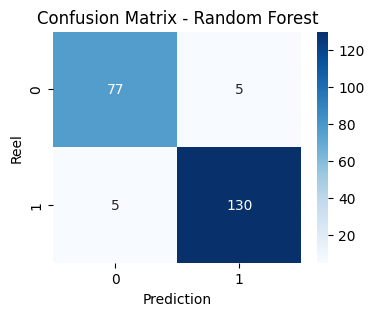

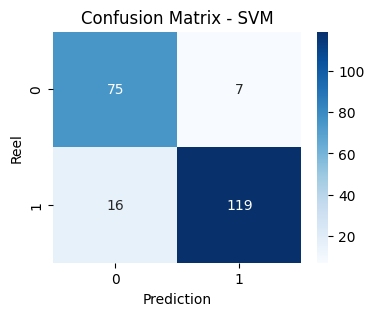

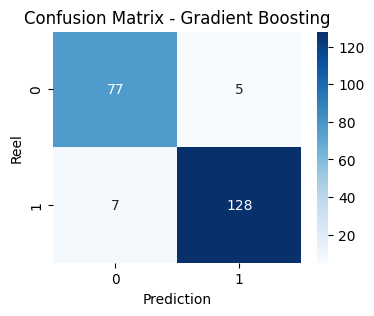

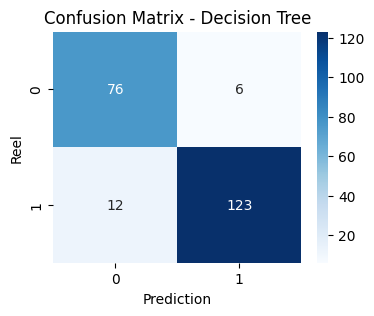

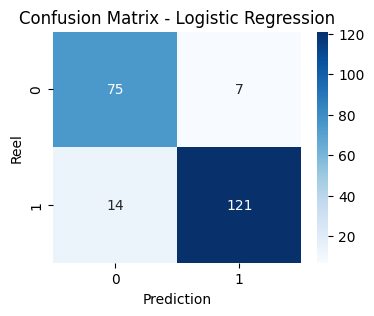

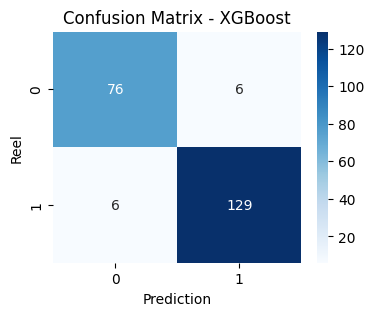


=== Resume comparatif des modeles ===
                Modele  Accuracy  Precision    Recall  F1-score
0        Random Forest  0.953917   0.962963  0.962963  0.962963
5              XGBoost  0.944700   0.955556  0.955556  0.955556
2    Gradient Boosting  0.944700   0.962406  0.948148  0.955224
3        Decision Tree  0.917051   0.953488  0.911111  0.931818
4  Logistic Regression  0.903226   0.945312  0.896296  0.920152
1                  SVM  0.894009   0.944444  0.881481  0.911877


In [105]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report



results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({"Modele": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1-score": f1})

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Prediction")
    plt.ylabel("Reel")
    plt.show()

df_results = pd.DataFrame(results).sort_values(by="F1-score", ascending=False)
print("\n=== Resume comparatif des modeles ===")
print(df_results)


In [109]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_val_score, StratifiedKFold


scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score)
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():
    print(f"\n🔹 Évaluation par validation croisée : {name}")
    scores = {}
    for metric, scorer in scoring.items():
        cv_scores = cross_val_score(model, X, y, cv=cv, scoring=scorer)
        scores[metric] = cv_scores.mean()
        print(f"{metric.capitalize()} moyenne: {cv_scores.mean():.4f} ")
   




🔹 Évaluation par validation croisée : Random Forest
Accuracy moyenne: 0.9167 
Precision moyenne: 0.9337 
Recall moyenne: 0.9333 
F1 moyenne: 0.9333 

🔹 Évaluation par validation croisée : SVM
Accuracy moyenne: 0.8752 
Precision moyenne: 0.8677 
Recall moyenne: 0.9444 
F1 moyenne: 0.9043 

🔹 Évaluation par validation croisée : Gradient Boosting
Accuracy moyenne: 0.9001 
Precision moyenne: 0.9134 
Recall moyenne: 0.9289 
F1 moyenne: 0.9208 

🔹 Évaluation par validation croisée : Decision Tree
Accuracy moyenne: 0.8501 
Precision moyenne: 0.8864 
Recall moyenne: 0.8733 
F1 moyenne: 0.8790 

🔹 Évaluation par validation croisée : Logistic Regression
Accuracy moyenne: 0.8987 
Precision moyenne: 0.9161 
Recall moyenne: 0.9222 
F1 moyenne: 0.9190 

🔹 Évaluation par validation croisée : XGBoost
Accuracy moyenne: 0.8945 
Precision moyenne: 0.9236 
Recall moyenne: 0.9067 
F1 moyenne: 0.9148 


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],         
    'max_depth': [None, 5, 10, 20],        
    'min_samples_split': [2, 5, 10],          
    'min_samples_leaf': [1, 2, 4],            
    'max_features': ['sqrt', 'log2']         
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
)

grid_search.fit(X_train_res, y_train_res)

print("\n🔹 Meilleurs parametres trouves :")
print(grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)



Fitting 5 folds for each of 216 candidates, totalling 1080 fits

🔹 Meilleurs parametres trouves :
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}


In [ ]:
import pickle

with open("random_forest_model.pkl", "wb") as f:
    pickle.dump(best_rf, f)

print("model saved")


In [116]:
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
